### Lab 2 : Neural Networks

In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

Data Preparation:

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv('mnist_train.csv')
t = df.iloc[:, 0] # the labels column
x = df.iloc[:, 1:] # the pixels columns
x_train_val , x_test, y_train_val, y_test = train_test_split(x , t , test_size=0.20, random_state=42 , stratify=t)
# Adding stratify=y ensures the split isn't random in a way that accidentally leaves all the "9s" in the test set

x_train, x_val, y_train, y_val = train_test_split(x_train_val , y_train_val , test_size=0.25, random_state=42 , stratify=y_train_val)

#check the splitting done correctly
print(f"Training shapes: {x_train.shape , y_train.shape}")
print(f"Validation shapes: {x_val.shape , y_val.shape}")
print(f"Testing shapes: {x_test.shape , y_test.shape}")


x_train = x_train/255.0
x_val = x_val/255.0
x_test = x_test/255.0

# Convert to PyTorch tensors el pictures el kter htt2sm batches

train_features = torch.tensor(x_train.values , dtype=torch.float32)
train_labels = torch.tensor(y_train.values , dtype=torch.long)

train_dataset = TensorDataset(train_features, train_labels)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True  # Shuffle the training data 
                              )

val_features = torch.tensor(x_val.values , dtype=torch.float32)
val_labels = torch.tensor(y_val.values , dtype=torch.long)
val_dataset = TensorDataset(val_features, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=64)

test_features = torch.tensor(x_test.values , dtype=torch.float32)
test_labels = torch.tensor(y_test.values , dtype=torch.long)
test_dataset = TensorDataset(test_features, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=64)


#CNN Data
x_train = x_train.values.reshape(-1, 1, 28, 28)

train_features = torch.tensor(x_train , dtype=torch.float32)

train_dataset = TensorDataset(train_features, train_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True  # Shuffle the training data 
                              )
x_val = x_val.values.reshape(-1, 1, 28, 28)
val_features = torch.tensor(x_val , dtype=torch.float32)

val_dataset = TensorDataset(val_features, val_labels)
val_loader = DataLoader(val_dataset, batch_size=64)

x_test = x_test.values.reshape(-1, 1, 28, 28)
test_features = torch.tensor(x_test , dtype=torch.float32)
test_dataset = TensorDataset(test_features, test_labels)
test_loader = DataLoader(test_dataset, batch_size=64)

Training shapes: ((36000, 784), (36000,))
Validation shapes: ((12000, 784), (12000,))
Testing shapes: ((12000, 784), (12000,))


In [3]:

class digit_recognition(nn.Module):
    def __init__(self):
        super().__init__()
        # 784 pixel input maps to 128 neuron  to 10 output (digits 0-9)
        # without sequential i have to define each layer separately and call each one to forward pass
        # 2 hidden layers
        self.model = nn.Sequential(
             nn.Linear(784 , 128 ), 
             nn.ReLU(), 
             nn.Linear(128 , 64),
             nn.ReLU(),
             nn.Linear(64 , 32 ),
             nn.ReLU(),
             nn.Linear(32 , 10)
             
         )
        self.loss_fn = nn.CrossEntropyLoss()
        #apply is built in method in torch that applies a function to every layer in the network
        self.apply(self._init_weights_)
         # Dropout layer with 20% dropout rate
    def _init_weights_(self , module):
        if isinstance(module , nn.Linear):
            nn.init.kaiming_normal_(module.weight , mode = 'fan_in' , nonlinearity='relu')
            if module.bias is not None:
             nn.init.zeros_(module.bias)
            
    def forward(self, x):
        return self.model(x)

    def training_step(self , train_dataloader, val_dataloader , epochs, lr = 0.01 ):
       

     optimizer = optim.SGD(self.parameters(), lr= lr)
     history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
     for epoch in range (epochs) :
         
         running_loss = 0.0 
         correct_predictions = 0
         total_predictions = 0
         
         for pixels , labels in train_dataloader :
                optimizer.zero_grad()  
                y_hat = self(pixels)  #foward pass
                current_loss = self.loss_fn(y_hat, labels) #compute  training loss
                # this loss is average loss across the batch size 
                current_loss.backward()    # Backpropagation to compute gradients
                optimizer.step()   # Update the weights (Gradient Descent)
                
                running_loss += current_loss.item() * labels.size(0)  # Accumulate total loss for whole batch
                
                predections = y_hat.argmax(dim=1)
                correct_predictions+= (predections==labels).sum().item()
                total_predictions += labels.size(0)  # Total number of predictions made
               
         train_loss  = running_loss / total_predictions
         train_accuracy = correct_predictions / total_predictions
         self.eval()
         val_loss_sum, val_correct, val_total = 0.0, 0, 0
 
         with torch.no_grad():                  
            for pixels, labels in val_dataloader:
                y_hat = self(pixels)
                loss  = self.loss_fn(y_hat, labels)
 
                val_loss_sum += loss.item() * labels.size(0)
                preds         = y_hat.argmax(dim=1)
                val_correct  += (preds == labels).sum().item()
                val_total    += labels.size(0)
 
         val_loss = val_loss_sum / val_total
         val_acc  = val_correct  / val_total
         history["train_loss"].append(train_loss)
         history["val_loss"].append(val_loss)
         history["train_acc"].append(train_accuracy)
         history["val_acc"].append(val_acc)
 
     print(f"Epoch {epoch:>2}/{epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_accuracy:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")
  
     return history


## Model Architecture

### Model Parameters
The `model.parameters()` contains the following structure:

- **Layer 1:** Weights (784 × 128) and Biases (128)
- **Layer 2:** Weights (128 × 64) and Biases (64)
- **Layer 3:** Weights (64 × 32) and Biases (32)
- **Layer 4:** Weights (32 × 10) and Biases (10)

---

## Training Mode & Dropout

### Setting Training Mode
```python
self.train()  # Set the model to training mode to enable dropout
```

**Purpose:** Enables training-specific behaviors like dropout, batch normalization updates, etc.

---

## Understanding Overfitting

### The Problem
When a neural network trains, it tries to minimize loss on the training data. If given enough capacity (layers, neurons), it can do this too well — it starts memorizing specific training examples rather than learning general patterns.

### Why Overfitting Happens: Co-adaptation

**Co-adaptation** is when neurons in a layer start to rely on each other in very specific ways.

#### Example: Three Co-adapted Neurons

Imagine neurons **A**, **B**, **C** working together:

- **Neuron A:** detects a curve at top
- **Neuron B:** detects a gap in middle  
- **Neuron C:** always fires to "fix" A's mistakes

**The Problem:**
- → C never learns anything useful on its own
- → The trio only works as a unit
- → Remove any one of them → whole prediction collapses

**Solution:** Dropout randomly deactivates neurons during training to force independent learning.

---

## Batch Size & Loss Calculation

### Why Multiply by Batch Size?

Since batch sizes are not always equal, we need to multiply the average loss by the batch size to get the total loss for that batch:

```python
running_loss += current_loss.item() * labels.size(0)
```

**Why?** The loss returned by `CrossEntropyLoss` is already averaged across the batch. To accumulate total loss across all batches:

$$\text{Total Loss} = \text{Batch Average Loss} \times \text{Batch Size}$$

---

## Digit Recognition Output Layer

### Output Structure

When training a model to recognize digits (0-9), the output layer has **10 neurons** — one per digit class.

For a single image, the output $(y\_{hat})$ is a vector of 10 numbers:

$$y_{hat} = [-1.2, 0.5, 6.2, -0.3, 0.1, 0.8, -2.1, 1.1, 0.0, -0.5]$$

### Class Mapping

- The **first number** (-1.2) corresponds to **class 0**
- The **second number** (0.5) corresponds to **class 1**
- The **third number** (6.2) corresponds to **class 2**
- And so on...

### Batch Dimensions

For a batch of multiple images:

$$y_{hat} \text{ shape} = (\text{batch size} \times 10 \text{ neurons})$$

---

## Making Predictions & Computing Accuracy

### Getting Predictions
```python
predictions = y_hat.argmax(dim=1)  # Get class with highest score for each image
```

### Counting Correct Predictions
```python
correct_predictions += (predictions == labels).sum().item()
```

#### Example

- **Correct labels** (ground truth): `[2, 3, 6]` for 3 images in batch
- **Predictions** (model output): `[2, 1, 6]`
- **Comparison:** `[True, False, True]` → `sum()` = **2 correct predictions**

### Total Predictions in Batch
```python
total_predictions += labels.size(0)
```

**Note:** We use `labels.size(0)` (not `labels.size()`) because:
- `labels.size()` returns a tensor object
- `labels.size(0)` returns an integer representing the dimension size
- We need the integer for accumulation

---

## Summary: Training Loop Metrics

| Metric | Calculation | Purpose |
|--------|-------------|---------|
| **Running Loss** | `sum(batch_loss × batch_size)` | Total loss across all batches |
| **Epoch Loss** | `running_loss / total_predictions` | Average loss per sample |
| **Correct Count** | `sum(predictions == labels)` | Count of correct predictions |
| **Epoch Accuracy** | `correct_count / total_predictions` | Percentage of correct predictions |


Epoch 19/20 | Train Loss: 0.0899  Acc: 0.9751 | Val Loss: 0.1452  Acc: 0.9572


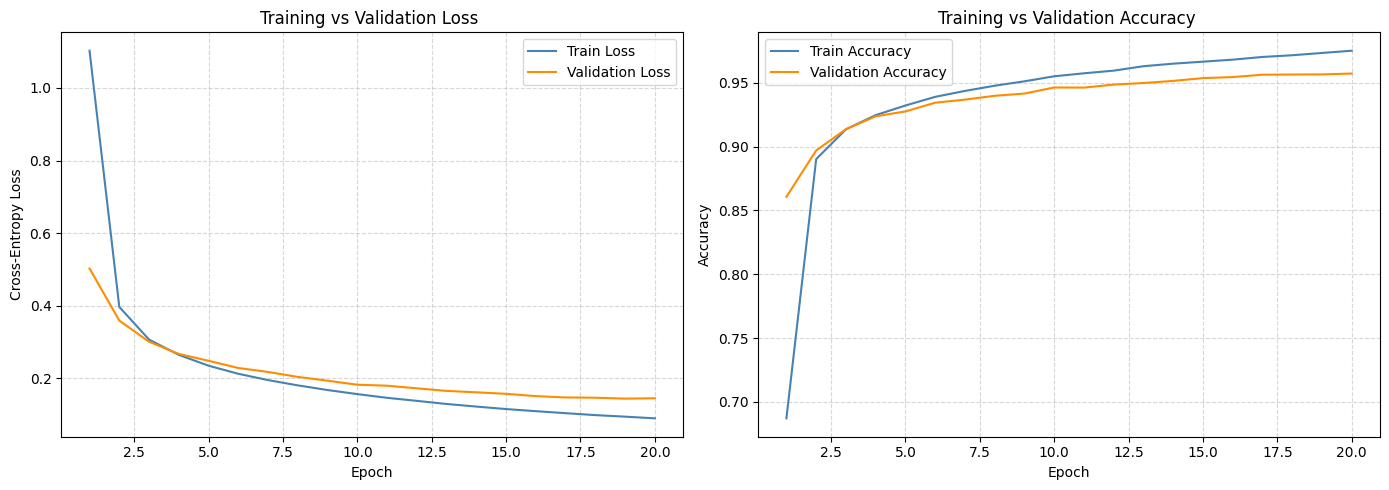

Plot saved → training_curves.png
Test Accuracy: 0.9586666666666667


In [4]:
def plot_history(history , title_suffix=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    # — Loss plot —
    ax1.plot(epochs, history["train_loss"], label="Train Loss",      color="steelblue")
    ax1.plot(epochs, history["val_loss"],   label="Validation Loss", color="darkorange")
    ax1.set_title("Training vs Validation Loss ")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)
 
    # — Accuracy plot —
    ax2.plot(epochs, history["train_acc"], label="Train Accuracy",      color="steelblue")
    ax2.plot(epochs, history["val_acc"],   label="Validation Accuracy", color="darkorange")
    ax2.set_title("Training vs Validation Accuracy ")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.5)
 
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Plot saved → training_curves.png")
 
 
# ─────────────────────────────────────────────
# 6. RUN EVERYTHING
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model   = digit_recognition()
    history = model.training_step( train_dataloader, val_dataloader, epochs=20, lr=0.01)
    plot_history(history )
    correct = 0
    total = 0


    with torch.no_grad():
      for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    print("Test Accuracy:", accuracy)


#Imagine you have 1,000 images and a Batch Size of 100.
#To complete 1 Epoch, the model needs to process 10 Batches.
#This means 1 Epoch = 10 Iterations.


# Analysis
 

In [5]:
# Model Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score
# evaluates the trained model on unseen test data using: Accuracy & Confusion Matrix
def evaluate_on_test(model, test_loader): 
    y_true = [] # stores actual labels
    y_pred = [] # stores predicted labels
#Dropout is a technique where random neurons are temporarily deactivated during training to prevent overfitting and improve the model’s ability to generalize.
    model.eval() #Disables dropout and training-specific behavior -> عشان اطلع احسن توقع 
    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x)
            preds = outputs.argmax(dim=1) #argmax selects the class with highest score
            # Store results
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())
    # Measures percentage of correct predictions (Accuracy)
    acc = accuracy_score(y_true, y_pred)
    print(f"Test Accuracy: {acc:.4f}")
    # Shows classification errors between classes
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc

In [6]:
# Analyze how different learning rates affect training performance and convergence.
def experiment_learning_rates(lrs, epochs=10):
    results = {}

    for lr in lrs:
        print(f"\n-Training with LR = {lr}")
        # Initializing a new model ensures fair comparison by starting each experiment from scratch without influence from previous training.
        model = digit_recognition()
        # Train model
        history = model.training_step(train_dataloader, val_dataloader, epochs=epochs, lr=lr)
        plot_history(history)
        final_val_acc = history["val_acc"][-1]  # Store only the final val accuracy for the summary bar chart
        results[lr] = final_val_acc
     # ── Summary bar chart: final val accuracy across all learning rates ──
    plt.figure(figsize=(7, 4))
    plt.bar([str(lr) for lr in lrs], [results[lr] for lr in lrs], color="steelblue")
    plt.title("Final Validation Accuracy vs Learning Rate")
    plt.xlabel("Learning Rate")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, lr in enumerate(lrs):
        plt.text(i, results[lr] + 0.01, f"{results[lr]:.4f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return results

## Learning Rate Analysis — Insights

- **High LR (0.1):** Converges fastest in the first few epochs but the loss curve tends to oscillate or even diverge because the weight updates overshoot the minimum.
- **Default LR (0.01):** Good balance — steady convergence, stable loss curve, strong final accuracy.
- **Low LR (0.001):** Converges smoothly but more slowly; may need more epochs to reach peak accuracy.
- **Very low LR (0.0001):** Barely moves in 10 epochs — the steps are too tiny. Loss stays high and accuracy lags far behind. This is classic underfitting due to insufficient learning.





-Training with LR = 0.1
Epoch  9/10 | Train Loss: 0.0245  Acc: 0.9931 | Val Loss: 0.1088  Acc: 0.9712


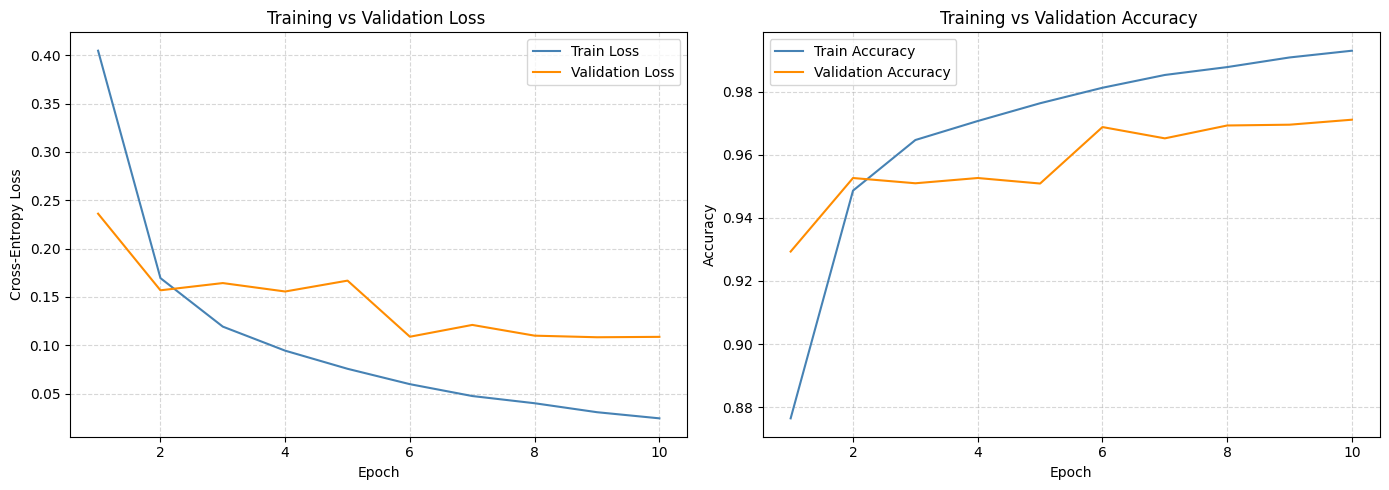

Plot saved → training_curves.png

-Training with LR = 0.01
Epoch  9/10 | Train Loss: 0.1624  Acc: 0.9531 | Val Loss: 0.1926  Acc: 0.9440


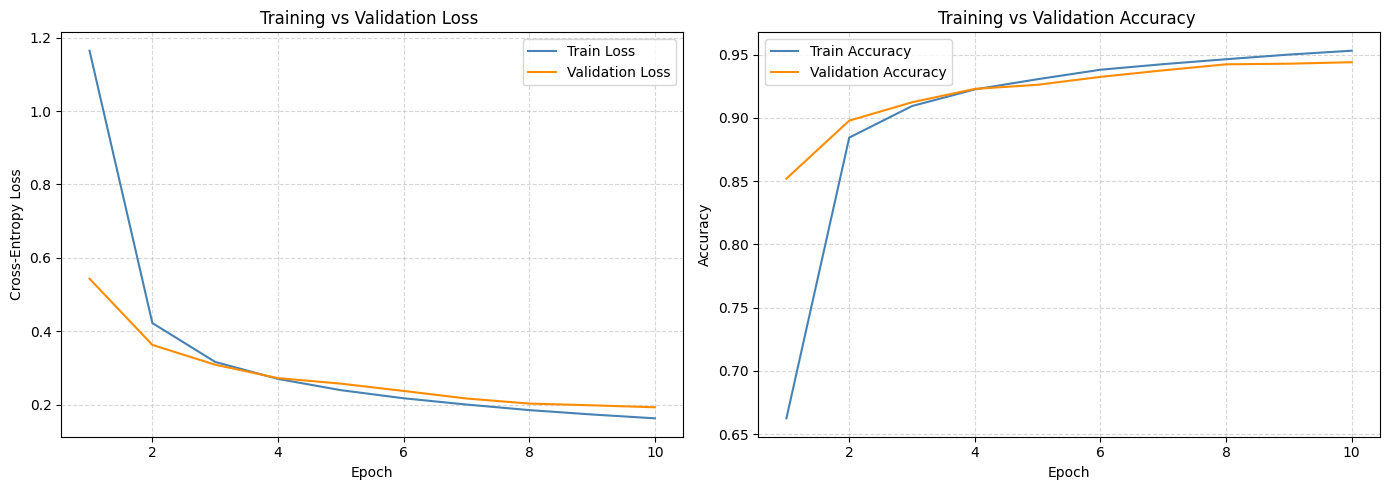

Plot saved → training_curves.png

-Training with LR = 0.001
Epoch  9/10 | Train Loss: 0.5160  Acc: 0.8603 | Val Loss: 0.5118  Acc: 0.8596


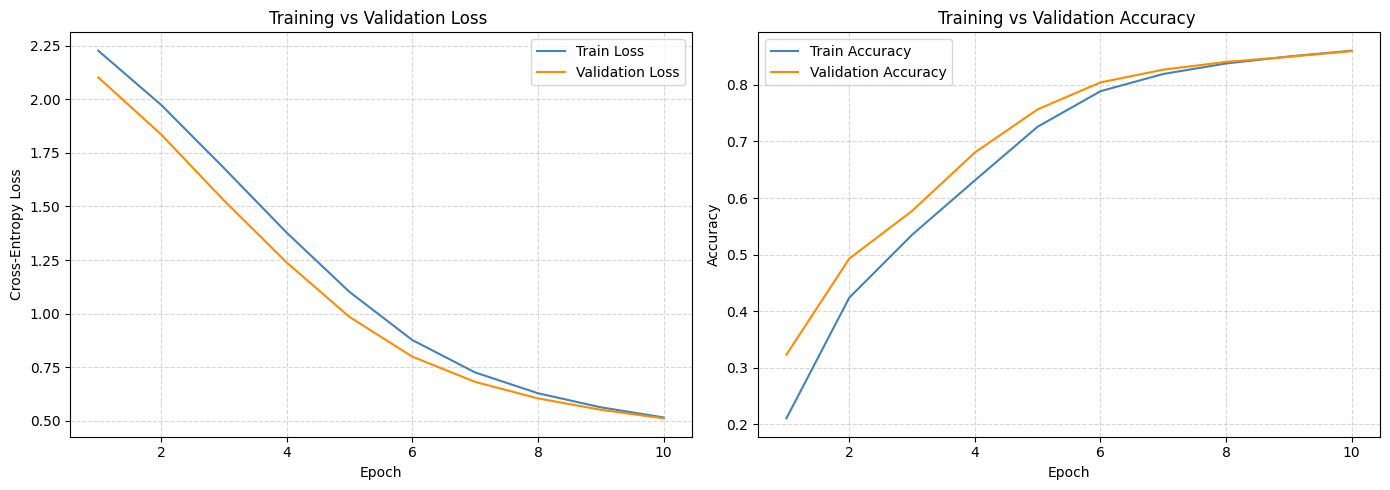

Plot saved → training_curves.png

-Training with LR = 0.0001
Epoch  9/10 | Train Loss: 1.9828  Acc: 0.3929 | Val Loss: 1.9661  Acc: 0.4040


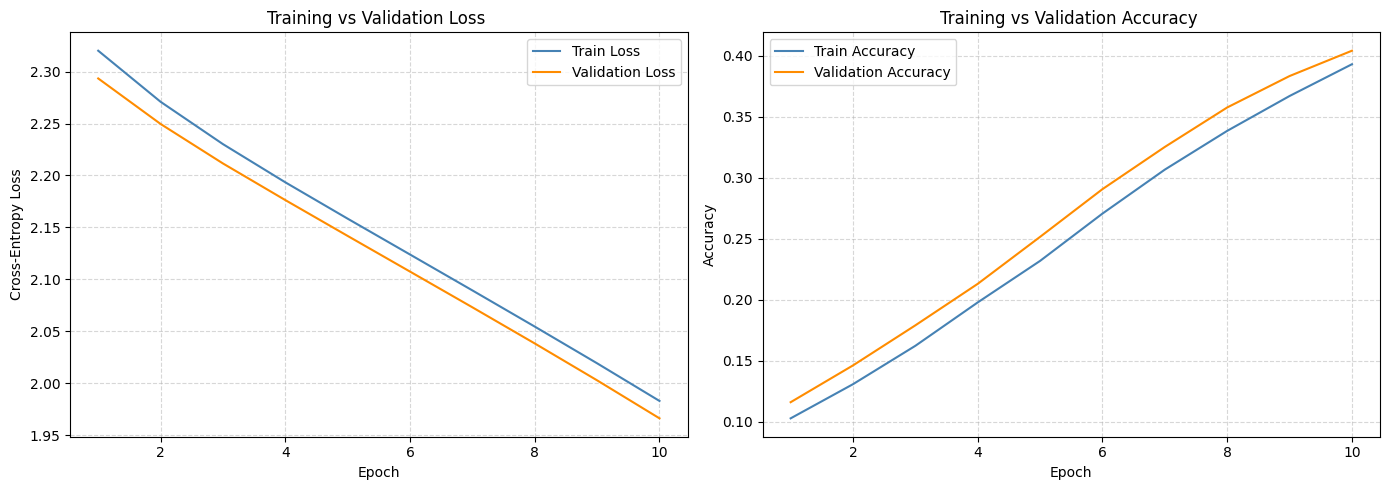

Plot saved → training_curves.png


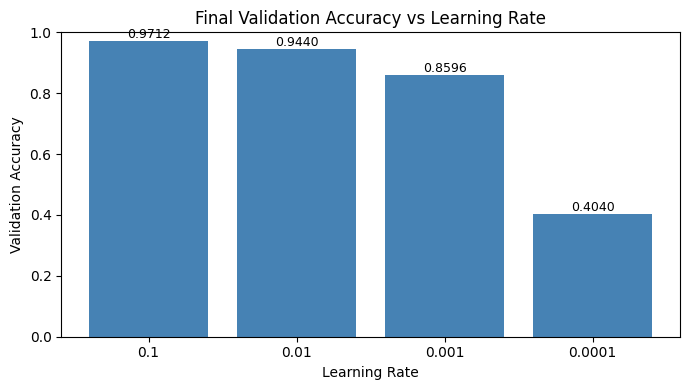

{0.1: 0.9711666666666666, 0.01: 0.944, 0.001: 0.8595833333333334, 0.0001: 0.404}


In [7]:
lr_results = experiment_learning_rates([0.1, 0.01, 0.001, 0.0001])
print(lr_results)

In [24]:
# Study how batch size affects training stability and generalization
def experiment_batch_sizes(batch_sizes, epochs=10):
    results = {}

    for bs in batch_sizes:
        print(f"\n-Training with Batch Size = {bs}")

        model = digit_recognition()
        history = model.training_step(train_dataloader, val_dataloader, epochs=epochs, lr=0.01)
        
        # Full training curves for this batch size
        plot_history(history, title_suffix=f"Batch={bs}")
        final_val_acc = history["val_acc"][-1]
        results[bs] = final_val_acc
     # ── Summary bar chart ──
    plt.figure(figsize=(7, 4))
    plt.bar([str(bs) for bs in batch_sizes], [results[bs] for bs in batch_sizes], color="darkorange")
    plt.title("Final Validation Accuracy vs Batch Size")
    plt.xlabel("Batch Size")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, bs in enumerate(batch_sizes):
        plt.text(i, results[bs] + 0.01, f"{results[bs]:.4f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return results

## Batch Size Analysis — Insights

- **Small batches (16, 32):** Each gradient update is computed from fewer samples, so the gradient estimate is noisier. This noise acts as implicit regularisation and often leads to better generalisation (higher val accuracy). However, training takes longer per epoch because there are more weight updates.
- **Medium batch (64):** Standard choice — good balance between speed and gradient quality.
- **Large batch (128):** Gradient estimates are very accurate (computed over many samples), so the loss curve is smooth. But the model tends to converge to "sharper" minima that generalise slightly worse. Each epoch is also faster because there are fewer updates.




-Training with Batch Size = 16
Epoch  9/10 | Train Loss: 0.1672  Acc: 0.9516 | Val Loss: 0.1977  Acc: 0.9426


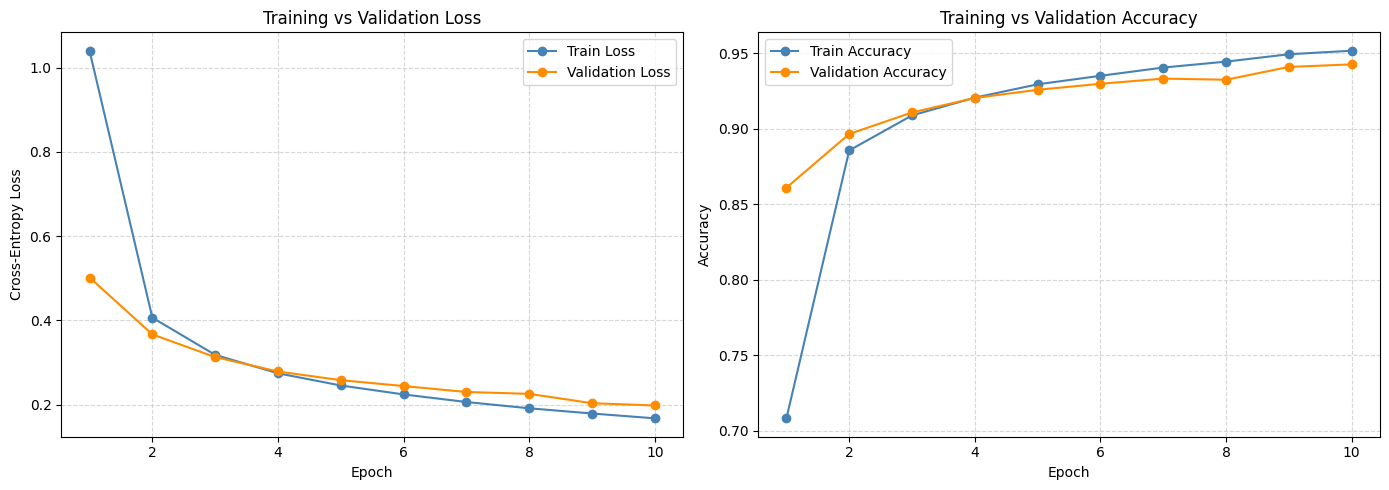

Plot saved → CNN_training_curves.png

-Training with Batch Size = 32
Epoch  9/10 | Train Loss: 0.1557  Acc: 0.9547 | Val Loss: 0.1811  Acc: 0.9458


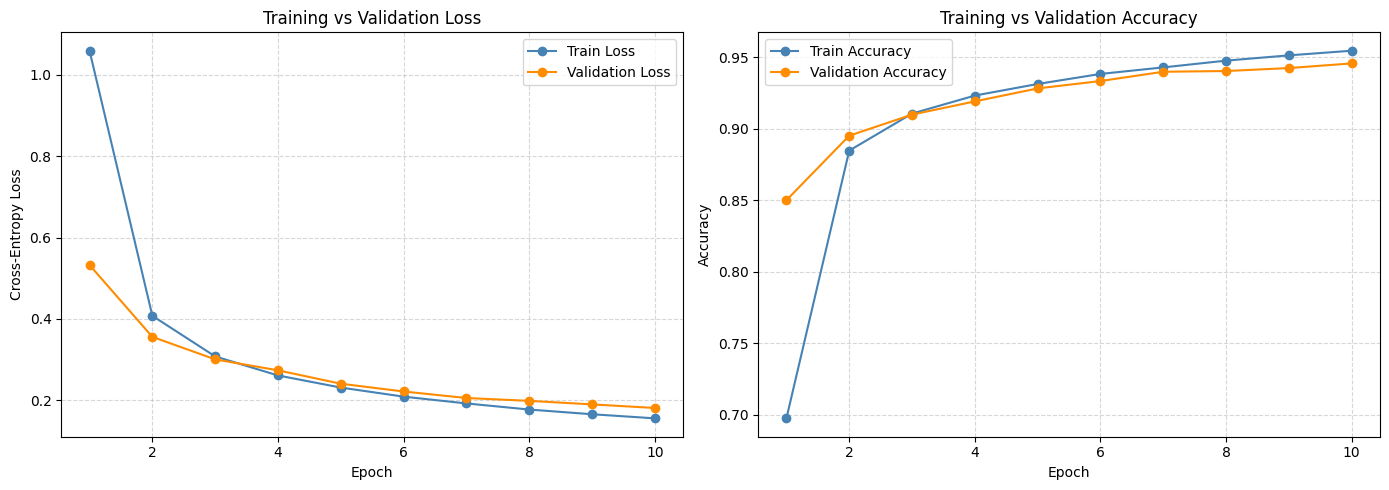

Plot saved → CNN_training_curves.png

-Training with Batch Size = 64
Epoch  9/10 | Train Loss: 0.1708  Acc: 0.9498 | Val Loss: 0.2003  Acc: 0.9409


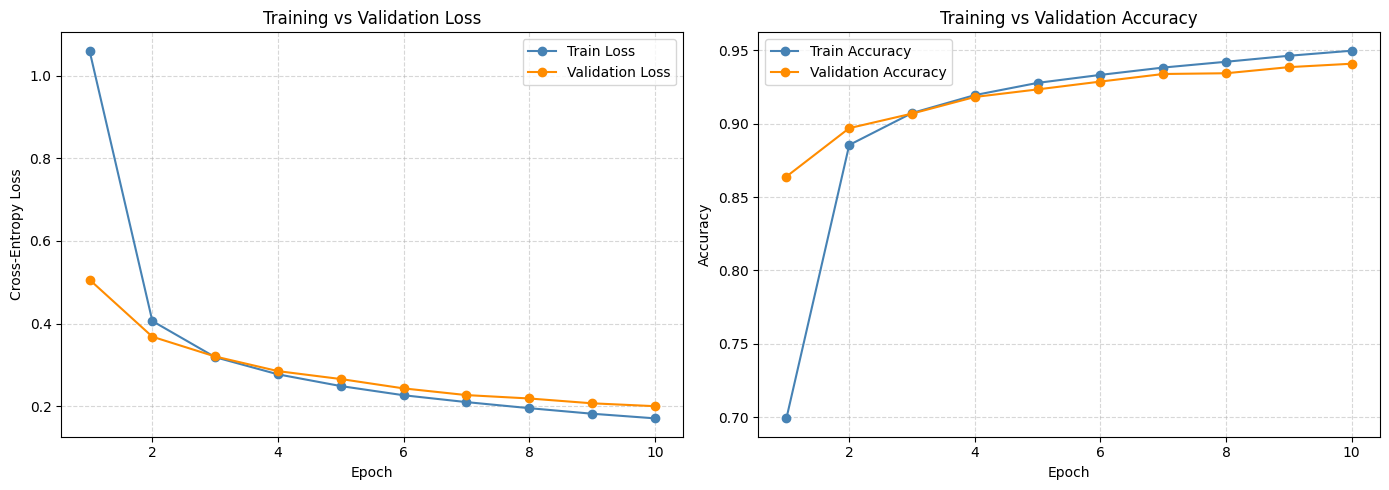

Plot saved → CNN_training_curves.png

-Training with Batch Size = 128
Epoch  9/10 | Train Loss: 0.1595  Acc: 0.9543 | Val Loss: 0.1915  Acc: 0.9441


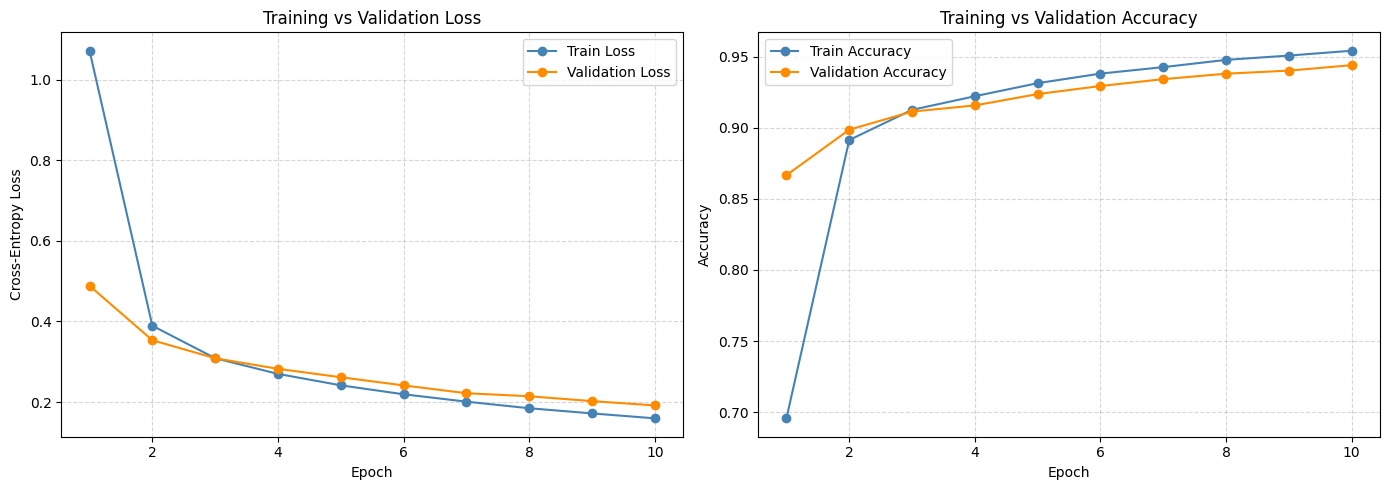

Plot saved → CNN_training_curves.png


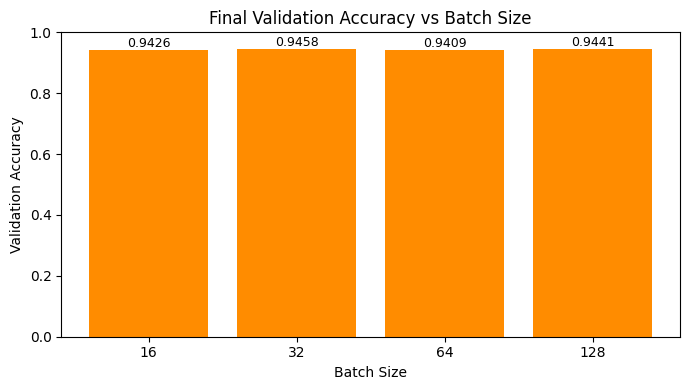

{16: 0.9425833333333333, 32: 0.9458333333333333, 64: 0.9409166666666666, 128: 0.9440833333333334}


In [25]:
bs_results = experiment_batch_sizes([16, 32, 64, 128])
print(bs_results)


--- Architecture: [64, 32, 16] ---
Epoch  0/10 | Train Loss: 2.2929  Acc: 0.1397 | Val Loss: 2.2659  Acc: 0.1833
Epoch  1/10 | Train Loss: 2.1450  Acc: 0.3052 | Val Loss: 1.8975  Acc: 0.3389
Epoch  2/10 | Train Loss: 1.4035  Acc: 0.5601 | Val Loss: 1.0279  Acc: 0.6951
Epoch  3/10 | Train Loss: 0.8248  Acc: 0.7547 | Val Loss: 0.7092  Acc: 0.7831
Epoch  4/10 | Train Loss: 0.6296  Acc: 0.8085 | Val Loss: 0.5901  Acc: 0.8177
Epoch  5/10 | Train Loss: 0.5353  Acc: 0.8381 | Val Loss: 0.5209  Acc: 0.8432
Epoch  6/10 | Train Loss: 0.4792  Acc: 0.8585 | Val Loss: 0.4833  Acc: 0.8599
Epoch  7/10 | Train Loss: 0.4398  Acc: 0.8712 | Val Loss: 0.4430  Acc: 0.8718
Epoch  8/10 | Train Loss: 0.4068  Acc: 0.8806 | Val Loss: 0.4162  Acc: 0.8805
Epoch  9/10 | Train Loss: 0.3765  Acc: 0.8899 | Val Loss: 0.3947  Acc: 0.8831


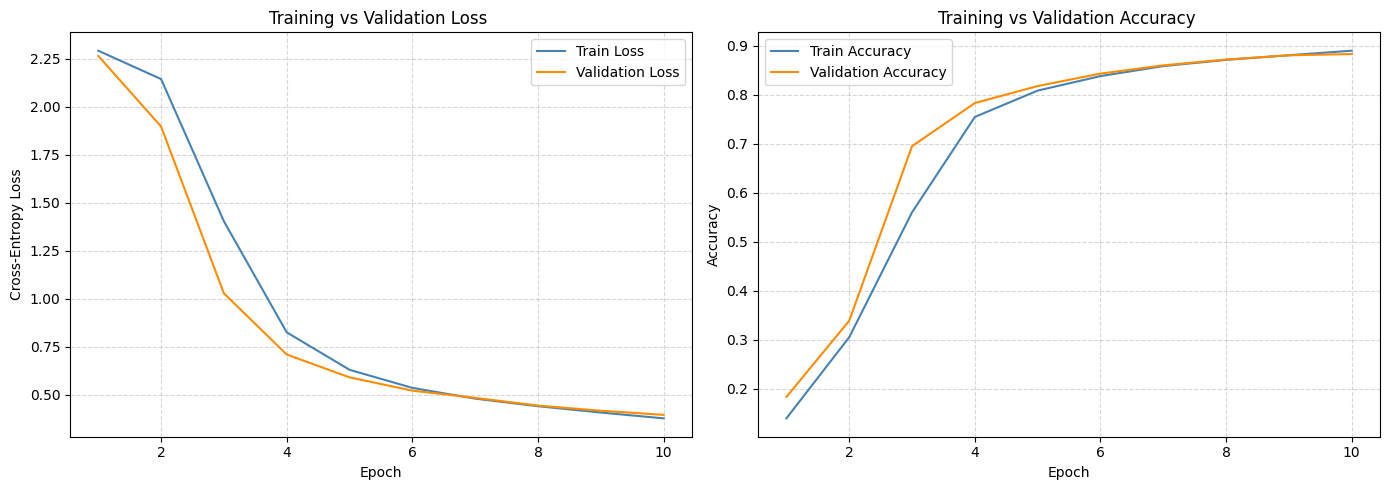

Plot saved → training_curves.png

--- Architecture: [128, 64, 32] ---
Epoch  0/10 | Train Loss: 2.2901  Acc: 0.1749 | Val Loss: 2.2677  Acc: 0.2777
Epoch  1/10 | Train Loss: 2.1706  Acc: 0.3874 | Val Loss: 1.9263  Acc: 0.4647
Epoch  2/10 | Train Loss: 1.2968  Acc: 0.6199 | Val Loss: 0.8578  Acc: 0.7278
Epoch  3/10 | Train Loss: 0.6975  Acc: 0.7833 | Val Loss: 0.6072  Acc: 0.8214
Epoch  4/10 | Train Loss: 0.5348  Acc: 0.8398 | Val Loss: 0.5081  Acc: 0.8528
Epoch  5/10 | Train Loss: 0.4594  Acc: 0.8656 | Val Loss: 0.4581  Acc: 0.8689
Epoch  6/10 | Train Loss: 0.4119  Acc: 0.8812 | Val Loss: 0.4134  Acc: 0.8801
Epoch  7/10 | Train Loss: 0.3753  Acc: 0.8924 | Val Loss: 0.3788  Acc: 0.8904
Epoch  8/10 | Train Loss: 0.3446  Acc: 0.9012 | Val Loss: 0.3563  Acc: 0.8969
Epoch  9/10 | Train Loss: 0.3208  Acc: 0.9085 | Val Loss: 0.3269  Acc: 0.9052


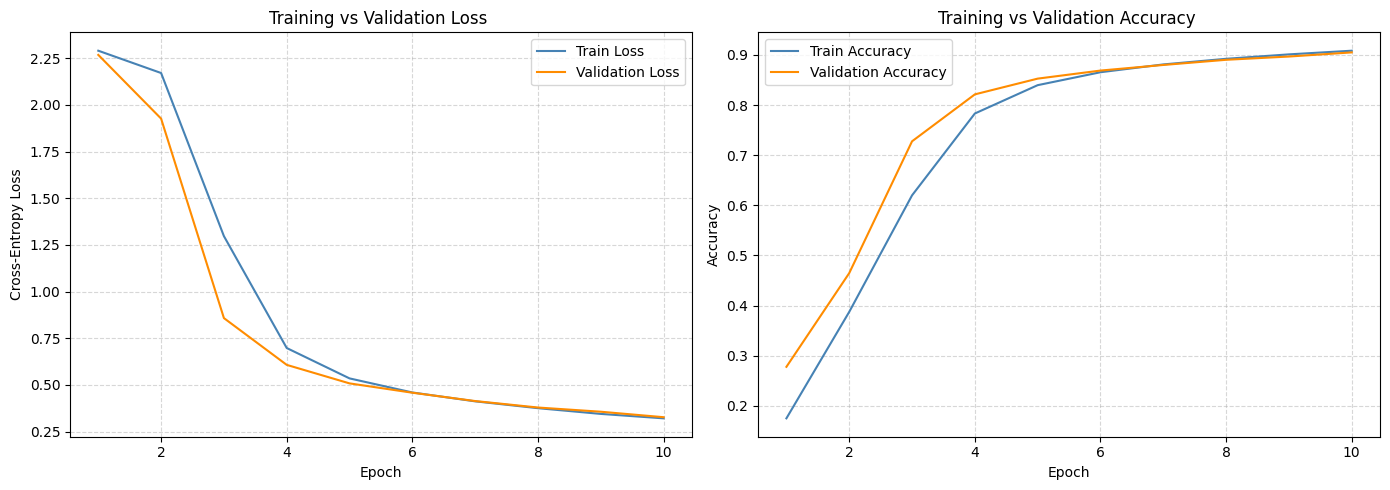

Plot saved → training_curves.png

--- Architecture: [256, 128, 64] ---
Epoch  0/10 | Train Loss: 2.2903  Acc: 0.1644 | Val Loss: 2.2693  Acc: 0.4565
Epoch  1/10 | Train Loss: 2.1644  Acc: 0.5567 | Val Loss: 1.8890  Acc: 0.5395
Epoch  2/10 | Train Loss: 1.2671  Acc: 0.6507 | Val Loss: 0.8907  Acc: 0.7084
Epoch  3/10 | Train Loss: 0.7202  Acc: 0.7902 | Val Loss: 0.6002  Acc: 0.8249
Epoch  4/10 | Train Loss: 0.5268  Acc: 0.8467 | Val Loss: 0.4876  Acc: 0.8628
Epoch  5/10 | Train Loss: 0.4396  Acc: 0.8742 | Val Loss: 0.4281  Acc: 0.8769
Epoch  6/10 | Train Loss: 0.3862  Acc: 0.8891 | Val Loss: 0.3869  Acc: 0.8872
Epoch  7/10 | Train Loss: 0.3493  Acc: 0.9002 | Val Loss: 0.3548  Acc: 0.8984
Epoch  8/10 | Train Loss: 0.3201  Acc: 0.9090 | Val Loss: 0.3279  Acc: 0.9066
Epoch  9/10 | Train Loss: 0.2977  Acc: 0.9150 | Val Loss: 0.3106  Acc: 0.9132


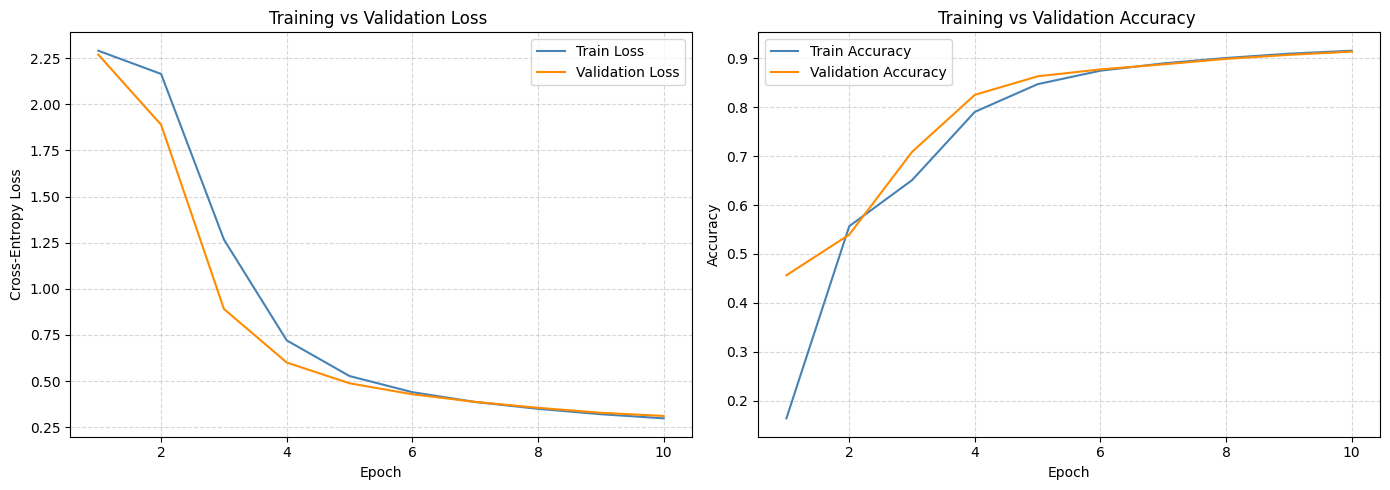

Plot saved → training_curves.png

--- Architecture: [512, 256, 128] ---
Epoch  0/10 | Train Loss: 2.2742  Acc: 0.2891 | Val Loss: 2.2211  Acc: 0.4843
Epoch  1/10 | Train Loss: 1.8860  Acc: 0.4950 | Val Loss: 1.2529  Acc: 0.6847
Epoch  2/10 | Train Loss: 0.8210  Acc: 0.7836 | Val Loss: 0.5993  Acc: 0.8207
Epoch  3/10 | Train Loss: 0.4982  Acc: 0.8564 | Val Loss: 0.4491  Acc: 0.8712
Epoch  4/10 | Train Loss: 0.4050  Acc: 0.8844 | Val Loss: 0.3939  Acc: 0.8871
Epoch  5/10 | Train Loss: 0.3625  Acc: 0.8956 | Val Loss: 0.3709  Acc: 0.8945
Epoch  6/10 | Train Loss: 0.3356  Acc: 0.9034 | Val Loss: 0.3458  Acc: 0.9022
Epoch  7/10 | Train Loss: 0.3126  Acc: 0.9096 | Val Loss: 0.3181  Acc: 0.9099
Epoch  8/10 | Train Loss: 0.2932  Acc: 0.9156 | Val Loss: 0.3035  Acc: 0.9141
Epoch  9/10 | Train Loss: 0.2752  Acc: 0.9201 | Val Loss: 0.2921  Acc: 0.9173


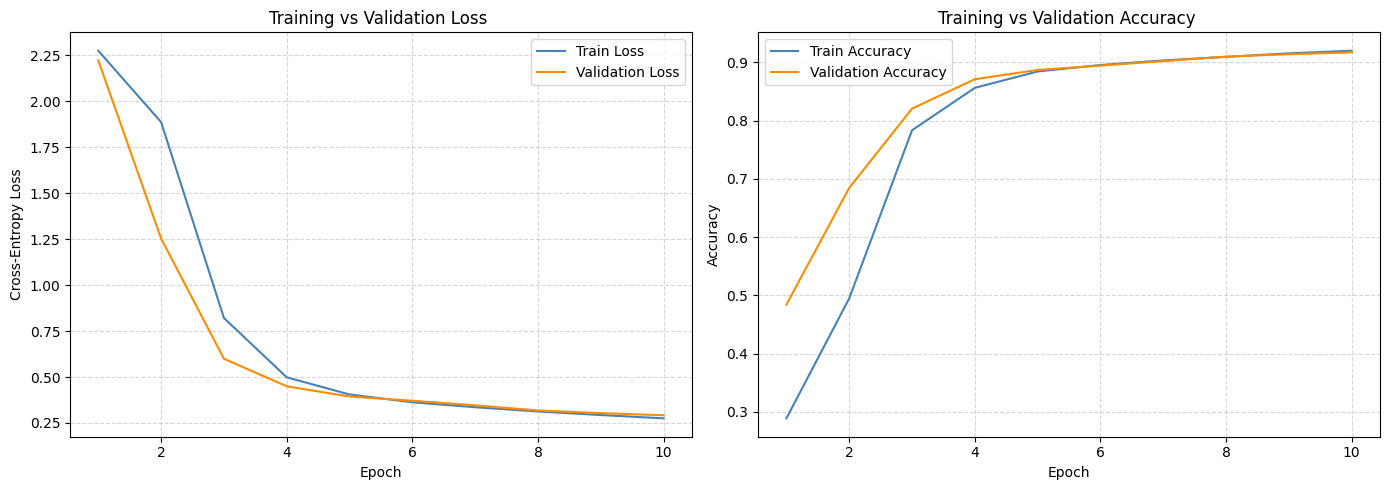

Plot saved → training_curves.png


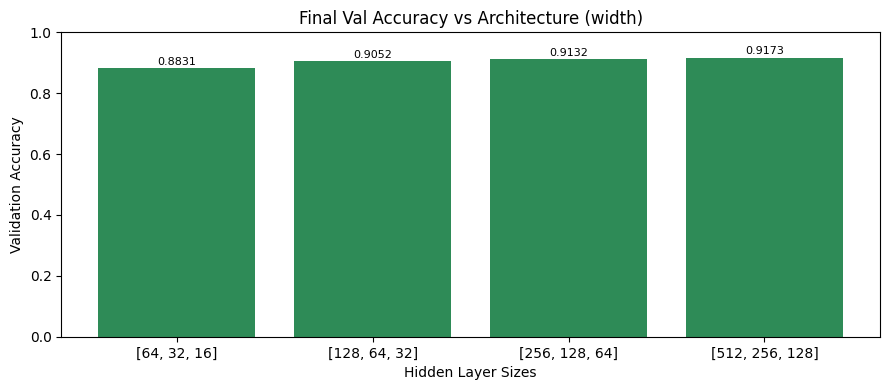

Width results: {'[64, 32, 16]': 0.8830833333333333, '[128, 64, 32]': 0.9051666666666667, '[256, 128, 64]': 0.9131666666666667, '[512, 256, 128]': 0.91725}

--- Architecture: [128] ---
Epoch  0/10 | Train Loss: 1.5810  Acc: 0.6823 | Val Loss: 0.9112  Acc: 0.8183
Epoch  1/10 | Train Loss: 0.6784  Acc: 0.8506 | Val Loss: 0.5529  Acc: 0.8669
Epoch  2/10 | Train Loss: 0.4845  Acc: 0.8770 | Val Loss: 0.4523  Acc: 0.8818
Epoch  3/10 | Train Loss: 0.4149  Acc: 0.8889 | Val Loss: 0.4067  Acc: 0.8887
Epoch  4/10 | Train Loss: 0.3782  Acc: 0.8956 | Val Loss: 0.3797  Acc: 0.8927
Epoch  5/10 | Train Loss: 0.3547  Acc: 0.9016 | Val Loss: 0.3609  Acc: 0.8978
Epoch  6/10 | Train Loss: 0.3378  Acc: 0.9042 | Val Loss: 0.3466  Acc: 0.9012
Epoch  7/10 | Train Loss: 0.3243  Acc: 0.9076 | Val Loss: 0.3361  Acc: 0.9043
Epoch  8/10 | Train Loss: 0.3134  Acc: 0.9116 | Val Loss: 0.3257  Acc: 0.9064
Epoch  9/10 | Train Loss: 0.3037  Acc: 0.9134 | Val Loss: 0.3178  Acc: 0.9089


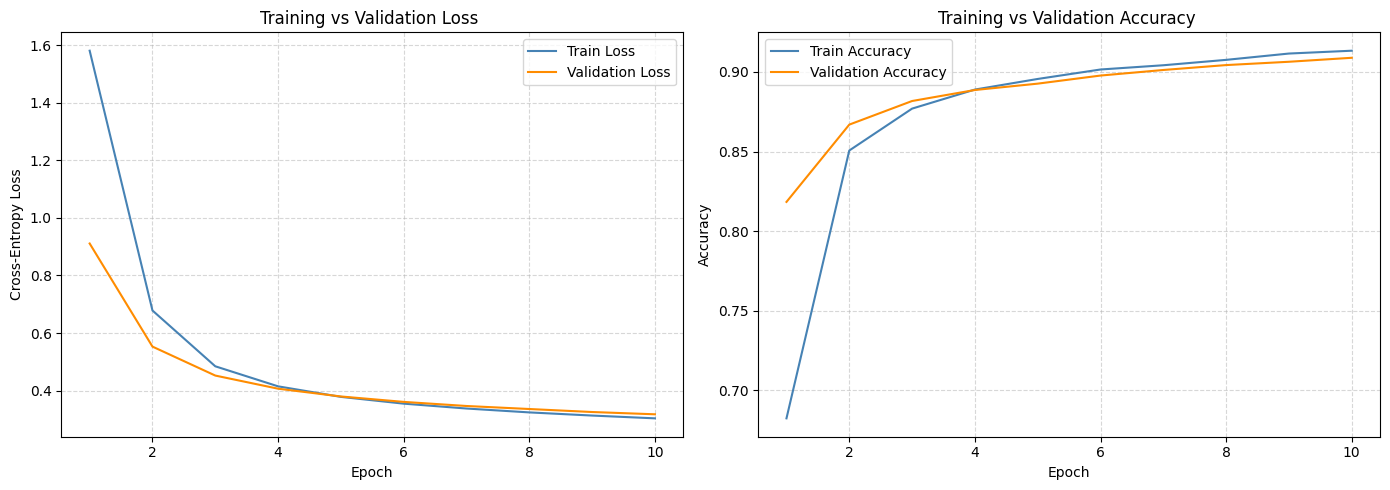

Plot saved → training_curves.png

--- Architecture: [128, 64] ---
Epoch  0/10 | Train Loss: 2.1144  Acc: 0.3961 | Val Loss: 1.6467  Acc: 0.6601
Epoch  1/10 | Train Loss: 1.0564  Acc: 0.7458 | Val Loss: 0.7162  Acc: 0.8103
Epoch  2/10 | Train Loss: 0.5809  Acc: 0.8434 | Val Loss: 0.4991  Acc: 0.8621
Epoch  3/10 | Train Loss: 0.4441  Acc: 0.8774 | Val Loss: 0.4204  Acc: 0.8826
Epoch  4/10 | Train Loss: 0.3843  Acc: 0.8916 | Val Loss: 0.3790  Acc: 0.8928
Epoch  5/10 | Train Loss: 0.3514  Acc: 0.8996 | Val Loss: 0.3611  Acc: 0.8956
Epoch  6/10 | Train Loss: 0.3297  Acc: 0.9053 | Val Loss: 0.3434  Acc: 0.8999
Epoch  7/10 | Train Loss: 0.3128  Acc: 0.9097 | Val Loss: 0.3263  Acc: 0.9073
Epoch  8/10 | Train Loss: 0.2990  Acc: 0.9141 | Val Loss: 0.3134  Acc: 0.9099
Epoch  9/10 | Train Loss: 0.2876  Acc: 0.9165 | Val Loss: 0.3012  Acc: 0.9143


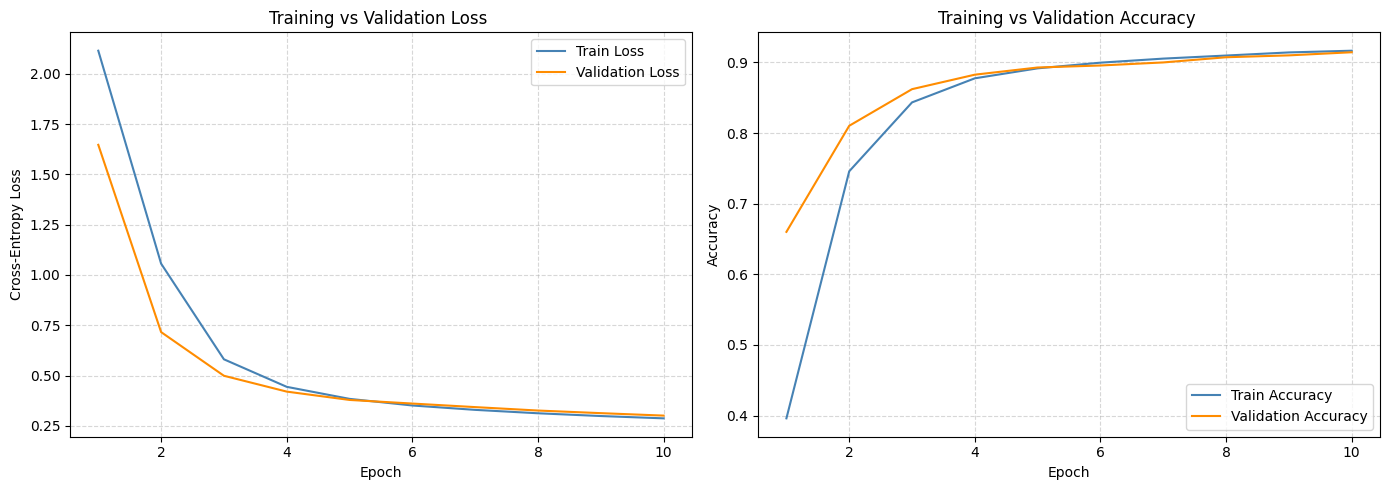

Plot saved → training_curves.png

--- Architecture: [128, 64, 32] ---
Epoch  0/10 | Train Loss: 2.2897  Acc: 0.1489 | Val Loss: 2.2675  Acc: 0.1875
Epoch  1/10 | Train Loss: 2.1742  Acc: 0.3297 | Val Loss: 1.9778  Acc: 0.4075
Epoch  2/10 | Train Loss: 1.4392  Acc: 0.5974 | Val Loss: 0.8851  Acc: 0.7380
Epoch  3/10 | Train Loss: 0.6728  Acc: 0.8053 | Val Loss: 0.5725  Acc: 0.8329
Epoch  4/10 | Train Loss: 0.5083  Acc: 0.8520 | Val Loss: 0.4780  Acc: 0.8612
Epoch  5/10 | Train Loss: 0.4418  Acc: 0.8716 | Val Loss: 0.4332  Acc: 0.8739
Epoch  6/10 | Train Loss: 0.3991  Acc: 0.8846 | Val Loss: 0.4005  Acc: 0.8835
Epoch  7/10 | Train Loss: 0.3646  Acc: 0.8952 | Val Loss: 0.3631  Acc: 0.8952
Epoch  8/10 | Train Loss: 0.3357  Acc: 0.9032 | Val Loss: 0.3447  Acc: 0.8982
Epoch  9/10 | Train Loss: 0.3109  Acc: 0.9106 | Val Loss: 0.3152  Acc: 0.9107


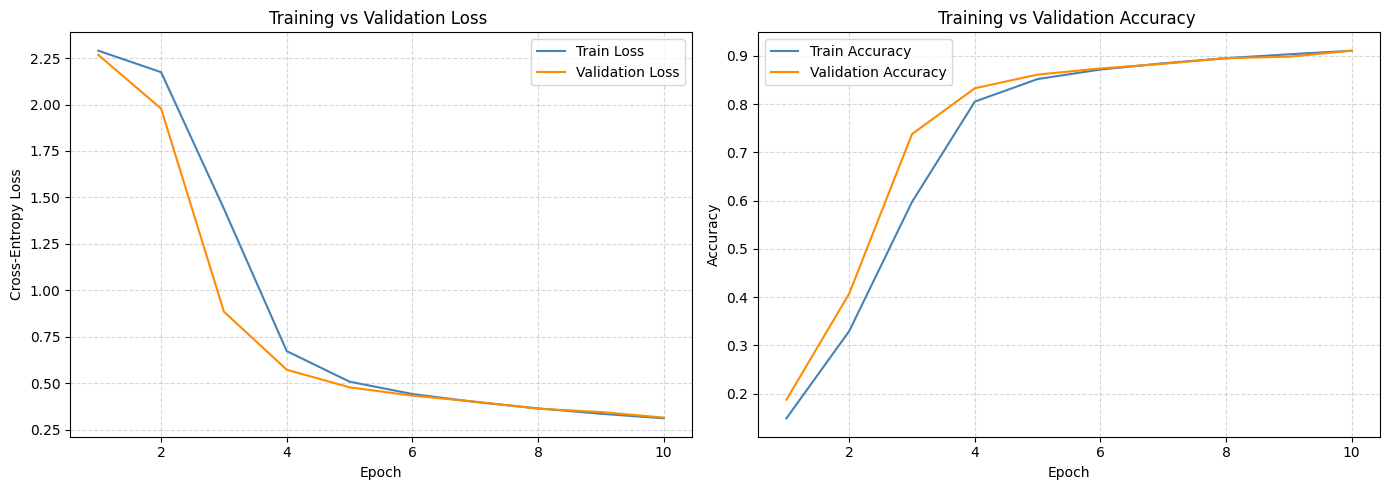

Plot saved → training_curves.png

--- Architecture: [128, 64, 32, 16] ---
Epoch  0/10 | Train Loss: 2.3025  Acc: 0.1044 | Val Loss: 2.2928  Acc: 0.1044
Epoch  1/10 | Train Loss: 2.2777  Acc: 0.1759 | Val Loss: 2.2528  Acc: 0.2846
Epoch  2/10 | Train Loss: 2.1304  Acc: 0.3234 | Val Loss: 1.8583  Acc: 0.3412
Epoch  3/10 | Train Loss: 1.4808  Acc: 0.4554 | Val Loss: 1.2215  Acc: 0.5412
Epoch  4/10 | Train Loss: 1.0452  Acc: 0.6322 | Val Loss: 0.9155  Acc: 0.6914
Epoch  5/10 | Train Loss: 0.7686  Acc: 0.7626 | Val Loss: 0.7294  Acc: 0.7795
Epoch  6/10 | Train Loss: 0.6481  Acc: 0.8078 | Val Loss: 0.6442  Acc: 0.8011
Epoch  7/10 | Train Loss: 0.5731  Acc: 0.8331 | Val Loss: 0.5715  Acc: 0.8280
Epoch  8/10 | Train Loss: 0.5051  Acc: 0.8557 | Val Loss: 0.4854  Acc: 0.8618
Epoch  9/10 | Train Loss: 0.4397  Acc: 0.8750 | Val Loss: 0.4280  Acc: 0.8791


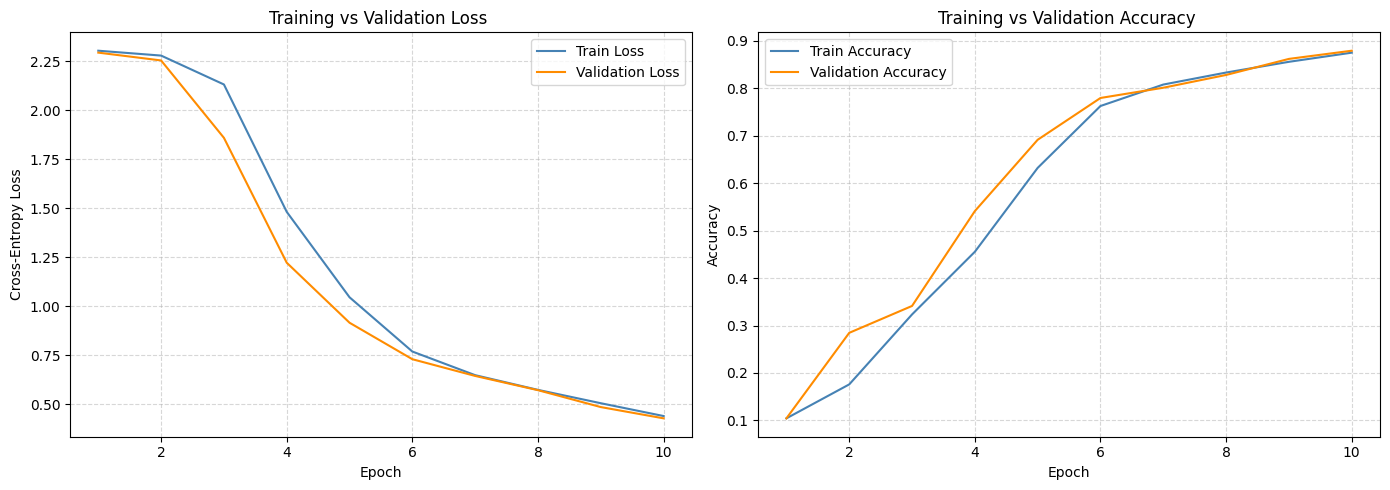

Plot saved → training_curves.png


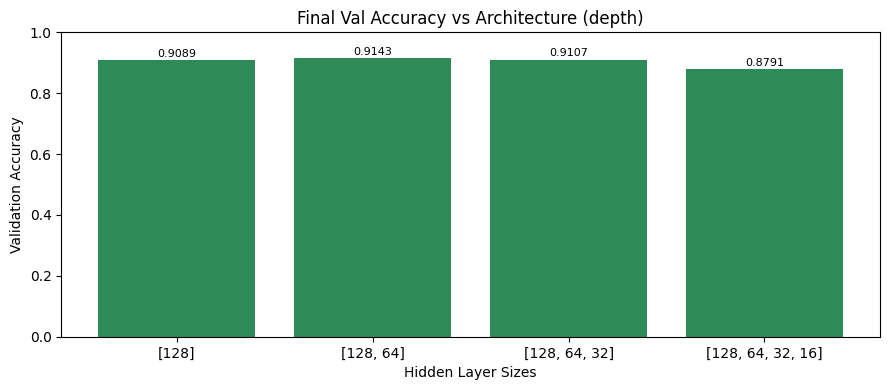

Depth results: {'[128]': 0.9089166666666667, '[128, 64]': 0.9143333333333333, '[128, 64, 32]': 0.9106666666666666, '[128, 64, 32, 16]': 0.8790833333333333}


In [11]:
# Evaluate the impact of changing both neuron count and number of layers.
#
# CustomNet now accepts a list of hidden sizes of any length, so we can test
# both different widths (neuron counts) and different depths (number of layers)
# in the same class without any changes.

class CustomNet(nn.Module):
    def __init__(self, hidden_sizes):
        """
        hidden_sizes : list of ints, e.g. [128, 64, 32]
                       → builds one hidden layer per element, then a 10-class output.
        """
        super().__init__()
        layers = []
        in_size = 784
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        layers.append(nn.Linear(in_size, 10))   # output layer
        self.model    = nn.Sequential(*layers)
        self.loss_fn  = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, train_loader, val_loader, epochs, lr=0.01):
        optimizer = optim.SGD(self.parameters(), lr=lr)
        # ← now tracks ALL 4 metrics so plot_history() works correctly
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        for epoch in range(epochs):
            # ── Training phase ──
            self.train()
            running_loss, correct, total = 0.0, 0, 0
            for x, y in train_loader:
                optimizer.zero_grad()
                out  = self(x)
                loss = self.loss_fn(out, y)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * y.size(0)
                correct      += (out.argmax(dim=1) == y).sum().item()
                total        += y.size(0)
            train_loss = running_loss / total
            train_acc  = correct / total

            # ── Validation phase ──
            self.eval()
            val_loss_sum, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for x, y in val_loader:
                    out  = self(x)
                    loss = self.loss_fn(out, y)
                    val_loss_sum += loss.item() * y.size(0)
                    val_correct  += (out.argmax(dim=1) == y).sum().item()
                    val_total    += y.size(0)
            val_loss = val_loss_sum / val_total
            val_acc  = val_correct  / val_total

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            print(f"Epoch {epoch:>2}/{epochs} | "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        return history


# ── Experiment A: vary neuron WIDTH (keep depth fixed at 3 hidden layers) ──
def experiment_neurons(configs, label="neurons"):
    results = {}
    for sizes in configs:
        label_str = str(sizes)
        print(f"\n--- Architecture: {label_str} ---")
        model = CustomNet(list(sizes))
        history = model.training_step(train_dataloader, val_dataloader, epochs=10)
        plot_history(history, title_suffix=f"Arch {label_str}")
        results[str(sizes)] = history["val_acc"][-1]

    # Summary bar chart
    plt.figure(figsize=(9, 4))
    plt.bar(list(results.keys()), list(results.values()), color="seagreen")
    plt.title(f"Final Val Accuracy vs Architecture ({label})")
    plt.xlabel("Hidden Layer Sizes")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, (k, v) in enumerate(results.items()):
        plt.text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()
    return results


# ── Neuron width experiment (depth = 3 hidden layers, width changes) ──
width_configs = [
    [64,  32,  16],
    [128, 64,  32],
    [256, 128, 64],
    [512, 256, 128],
]
width_results = experiment_neurons(width_configs, label="width")
print("Width results:", width_results)


# ── Depth experiment (width ≈ fixed ~128, number of hidden layers changes) ──
depth_configs = [
    [128],                    # 1 hidden layer
    [128, 64],                # 2 hidden layers
    [128, 64, 32],            # 3 hidden layers
    [128, 64, 32, 16],        # 4 hidden layers
]
depth_results = experiment_neurons(depth_configs, label="depth")
print("Depth results:", depth_results)


## Architecture Analysis — Insights

### Neuron Width (fixed 3 layers, changing neuron count)
- **Narrow networks [64,32,16]:** Limited capacity → underfits slightly; the bottleneck at 16 neurons before the output forces too much compression.
- **Medium [128,64,32]:** Usually the sweet spot on MNIST — enough capacity without wasting computation.
- **Wide [256,128,64] and [512,256,128]:** Marginal or no improvement over medium on MNIST because the task is not complex enough to need that many parameters. Training may also be slightly slower.

### Network Depth (fixed width ≈128, changing number of layers)
- **1 hidden layer:** Can still reach decent accuracy on MNIST (it is a simple dataset), but it misses some feature hierarchies.
- **2–3 hidden layers:** Better feature abstraction; generally higher accuracy.
- **4 hidden layers:** On simple tasks like MNIST, very deep networks with SGD can sometimes train slower because gradients weaken as they travel back through many layers (vanishing gradient). ReLU helps, but it does not fully eliminate the issue.




Increasing neurons improves performance slightly

MNIST is simple → large networks not necessary


--- Architecture: [64, 32, 16] ---
Epoch  0/10 | Train Loss: 2.2943  Acc: 0.1474 | Val Loss: 2.2738  Acc: 0.2572
Epoch  1/10 | Train Loss: 2.1973  Acc: 0.3185 | Val Loss: 2.0138  Acc: 0.4098
Epoch  2/10 | Train Loss: 1.4740  Acc: 0.5461 | Val Loss: 1.0231  Acc: 0.6738
Epoch  3/10 | Train Loss: 0.8183  Acc: 0.7354 | Val Loss: 0.7049  Acc: 0.7758
Epoch  4/10 | Train Loss: 0.6316  Acc: 0.8013 | Val Loss: 0.5965  Acc: 0.8173
Epoch  5/10 | Train Loss: 0.5330  Acc: 0.8405 | Val Loss: 0.5150  Acc: 0.8433
Epoch  6/10 | Train Loss: 0.4570  Acc: 0.8671 | Val Loss: 0.4390  Acc: 0.8723
Epoch  7/10 | Train Loss: 0.3997  Acc: 0.8852 | Val Loss: 0.3943  Acc: 0.8863
Epoch  8/10 | Train Loss: 0.3588  Acc: 0.8966 | Val Loss: 0.3608  Acc: 0.8974
Epoch  9/10 | Train Loss: 0.3274  Acc: 0.9059 | Val Loss: 0.3352  Acc: 0.9027


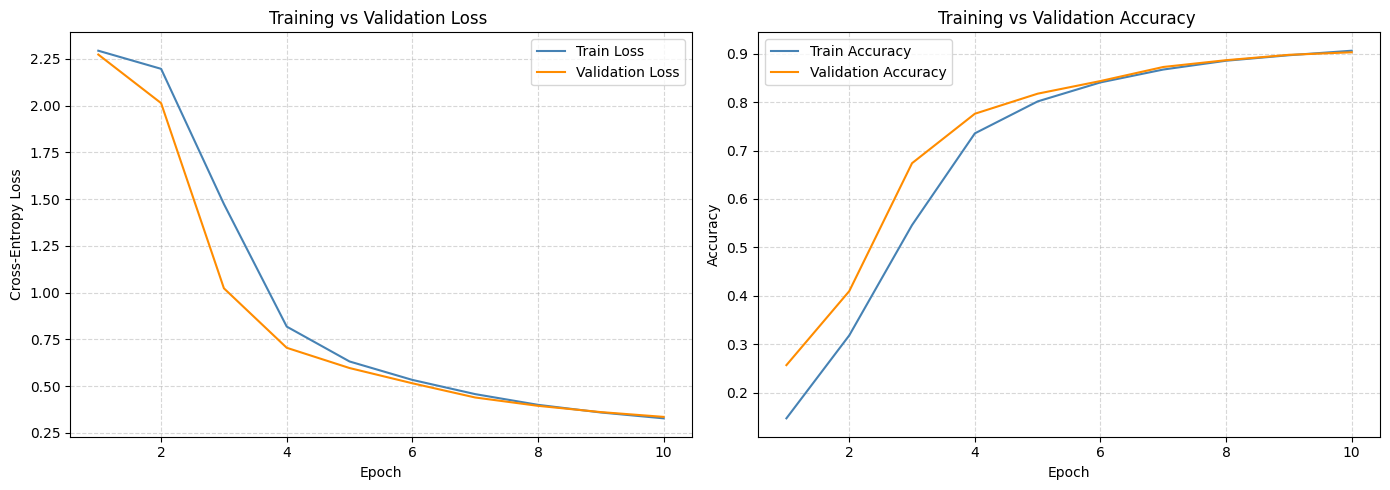

Plot saved → training_curves.png

--- Architecture: [128, 64, 32] ---
Epoch  0/10 | Train Loss: 2.2832  Acc: 0.2014 | Val Loss: 2.2455  Acc: 0.3193
Epoch  1/10 | Train Loss: 2.0400  Acc: 0.4279 | Val Loss: 1.5687  Acc: 0.4971
Epoch  2/10 | Train Loss: 1.0256  Acc: 0.6968 | Val Loss: 0.7051  Acc: 0.7884
Epoch  3/10 | Train Loss: 0.5675  Acc: 0.8358 | Val Loss: 0.4976  Acc: 0.8586
Epoch  4/10 | Train Loss: 0.4475  Acc: 0.8723 | Val Loss: 0.4333  Acc: 0.8754
Epoch  5/10 | Train Loss: 0.3993  Acc: 0.8853 | Val Loss: 0.4068  Acc: 0.8810
Epoch  6/10 | Train Loss: 0.3690  Acc: 0.8935 | Val Loss: 0.3741  Acc: 0.8932
Epoch  7/10 | Train Loss: 0.3452  Acc: 0.8999 | Val Loss: 0.3537  Acc: 0.9018
Epoch  8/10 | Train Loss: 0.3251  Acc: 0.9059 | Val Loss: 0.3347  Acc: 0.9058
Epoch  9/10 | Train Loss: 0.3079  Acc: 0.9121 | Val Loss: 0.3215  Acc: 0.9103


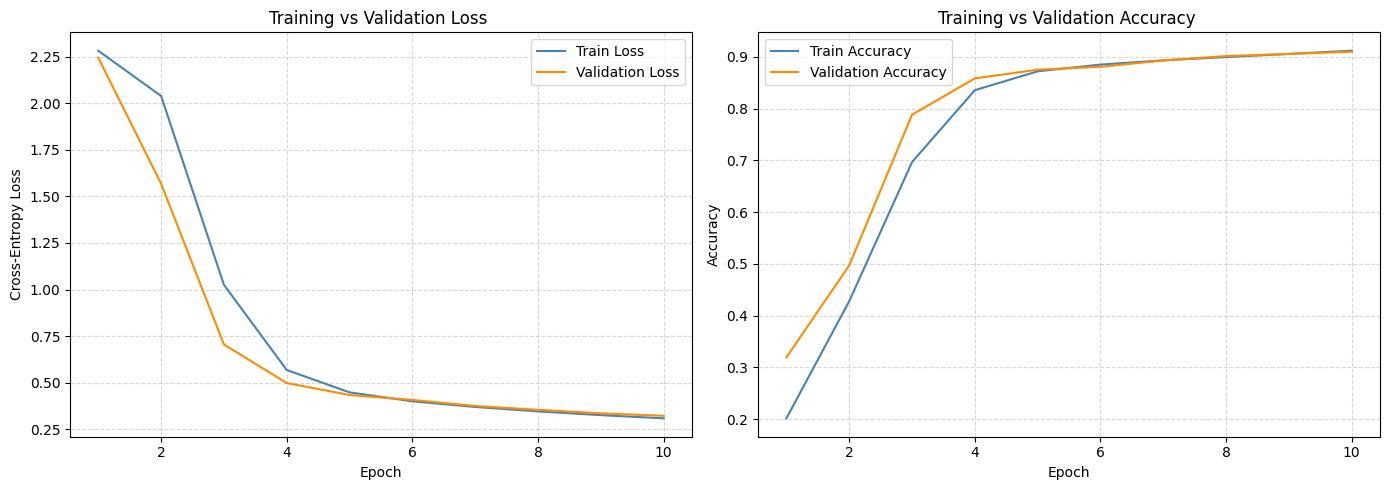

Plot saved → training_curves.png

--- Architecture: [256, 128, 64] ---
Epoch  0/10 | Train Loss: 2.2784  Acc: 0.2024 | Val Loss: 2.2307  Acc: 0.4828
Epoch  1/10 | Train Loss: 1.9409  Acc: 0.4370 | Val Loss: 1.4533  Acc: 0.5767
Epoch  2/10 | Train Loss: 0.9890  Acc: 0.7289 | Val Loss: 0.6975  Acc: 0.8017
Epoch  3/10 | Train Loss: 0.5751  Acc: 0.8310 | Val Loss: 0.5156  Acc: 0.8477
Epoch  4/10 | Train Loss: 0.4536  Acc: 0.8687 | Val Loss: 0.4449  Acc: 0.8662
Epoch  5/10 | Train Loss: 0.3962  Acc: 0.8862 | Val Loss: 0.3934  Acc: 0.8876
Epoch  6/10 | Train Loss: 0.3602  Acc: 0.8958 | Val Loss: 0.3680  Acc: 0.8918
Epoch  7/10 | Train Loss: 0.3335  Acc: 0.9044 | Val Loss: 0.3412  Acc: 0.9041
Epoch  8/10 | Train Loss: 0.3104  Acc: 0.9108 | Val Loss: 0.3189  Acc: 0.9095
Epoch  9/10 | Train Loss: 0.2890  Acc: 0.9159 | Val Loss: 0.2999  Acc: 0.9147


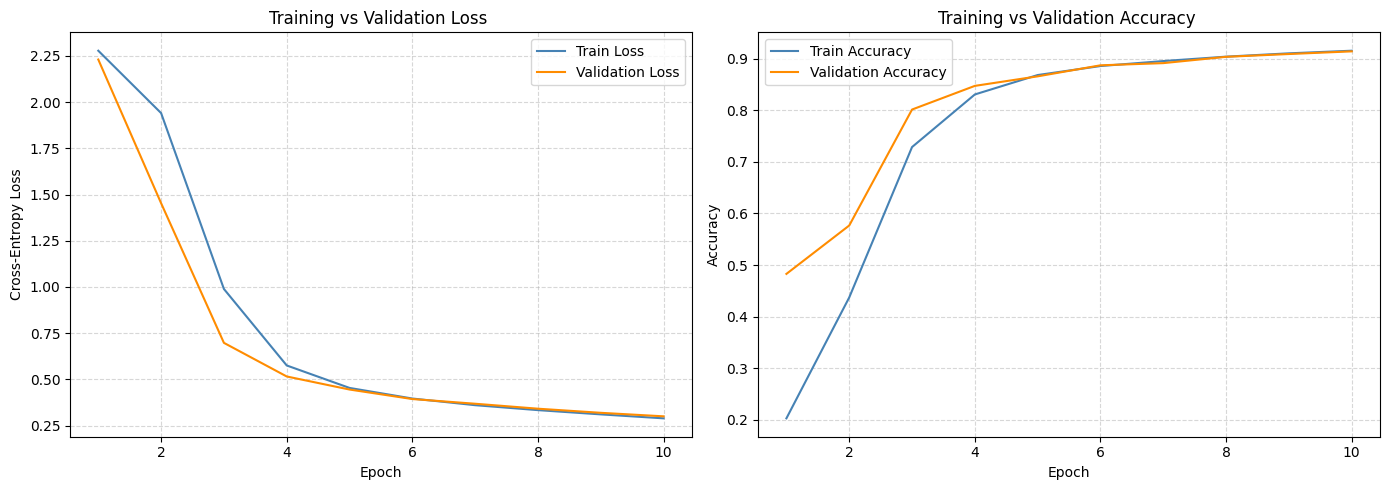

Plot saved → training_curves.png

--- Architecture: [512, 256, 128] ---
Epoch  0/10 | Train Loss: 2.2712  Acc: 0.2502 | Val Loss: 2.2088  Acc: 0.3813
Epoch  1/10 | Train Loss: 1.8736  Acc: 0.5358 | Val Loss: 1.2829  Acc: 0.6960
Epoch  2/10 | Train Loss: 0.8371  Acc: 0.7756 | Val Loss: 0.6192  Acc: 0.8231
Epoch  3/10 | Train Loss: 0.5259  Acc: 0.8506 | Val Loss: 0.4768  Acc: 0.8634
Epoch  4/10 | Train Loss: 0.4283  Acc: 0.8777 | Val Loss: 0.4129  Acc: 0.8810
Epoch  5/10 | Train Loss: 0.3764  Acc: 0.8918 | Val Loss: 0.3832  Acc: 0.8893
Epoch  6/10 | Train Loss: 0.3430  Acc: 0.9006 | Val Loss: 0.3513  Acc: 0.8997
Epoch  7/10 | Train Loss: 0.3167  Acc: 0.9090 | Val Loss: 0.3268  Acc: 0.9083
Epoch  8/10 | Train Loss: 0.2944  Acc: 0.9165 | Val Loss: 0.3052  Acc: 0.9133
Epoch  9/10 | Train Loss: 0.2742  Acc: 0.9222 | Val Loss: 0.2966  Acc: 0.9147


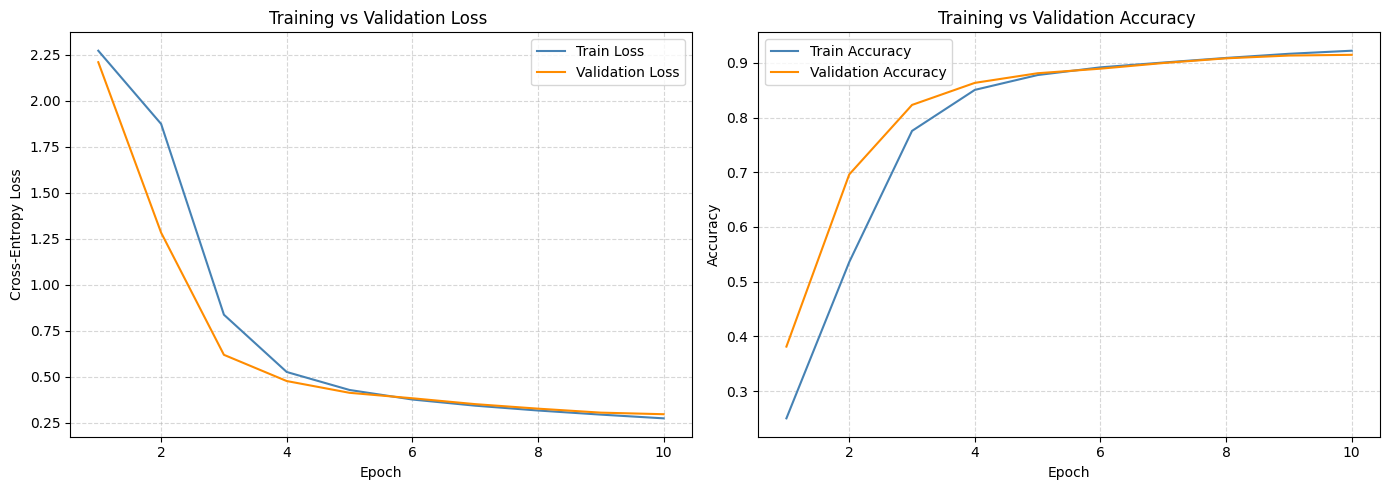

Plot saved → training_curves.png
{'[64, 32, 16]': 0.9026666666666666, '[128, 64, 32]': 0.91025, '[256, 128, 64]': 0.9146666666666666, '[512, 256, 128]': 0.9146666666666666}


In [12]:
def experiment_neurons(configs, label="neurons"):
    results = {}

    for sizes in configs:
        label_str = str(sizes)
        print(f"\n--- Architecture: {label_str} ---")

        model = CustomNet(sizes)
        history = model.training_step(train_dataloader, val_dataloader, epochs=10)
        plot_history(history, title_suffix=f"Arch {label_str}")

        results[label_str] = history["val_acc"][-1]

    return results

configs = [[64, 32, 16], [128, 64, 32], [256, 128, 64], [512, 256, 128]]
neuron_results = experiment_neurons(configs, label="width")

print(neuron_results)


## Best Model — Final Evaluation on Test Set

Epoch  9/10 | Train Loss: 0.1590  Acc: 0.9548 | Val Loss: 0.1811  Acc: 0.9473


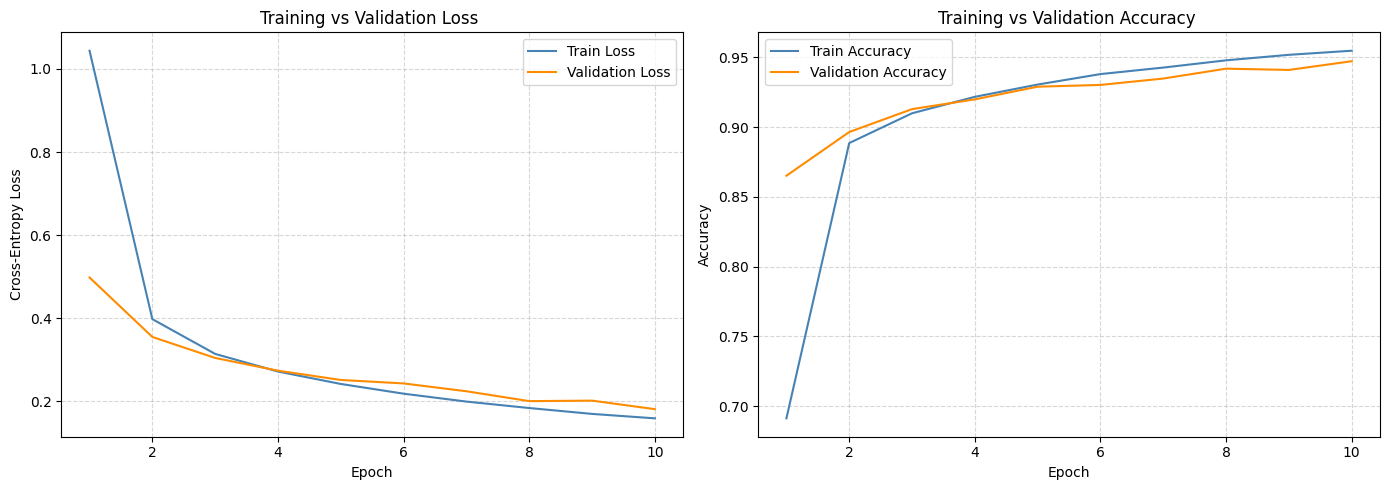

Plot saved → training_curves.png
Test Accuracy: 0.9503


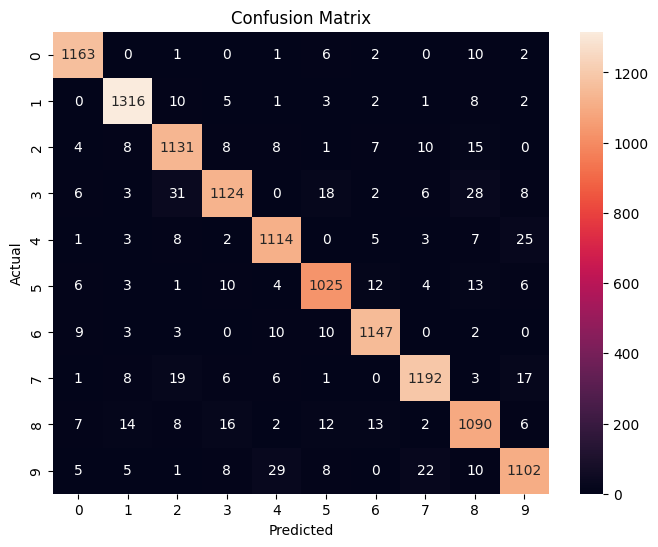

In [13]:
# Train the best model configuration and evaluate it on test data.
best_model = digit_recognition()
history = best_model.training_step(train_dataloader, val_dataloader, epochs=10, lr=0.01)

plot_history(history)

test_acc = evaluate_on_test(best_model, test_dataloader)

## Bonus Part - Convolutional Neural Network (CNN)
In this part we will implement same functionality with different architecture. The CNN architecture enhance the model for the following: 
- If a digit get shifted a little, model still recognise it
- Significantly reduce the number of parameters
- CNNs treat images like structured visual data

## Layers are introduced as following:
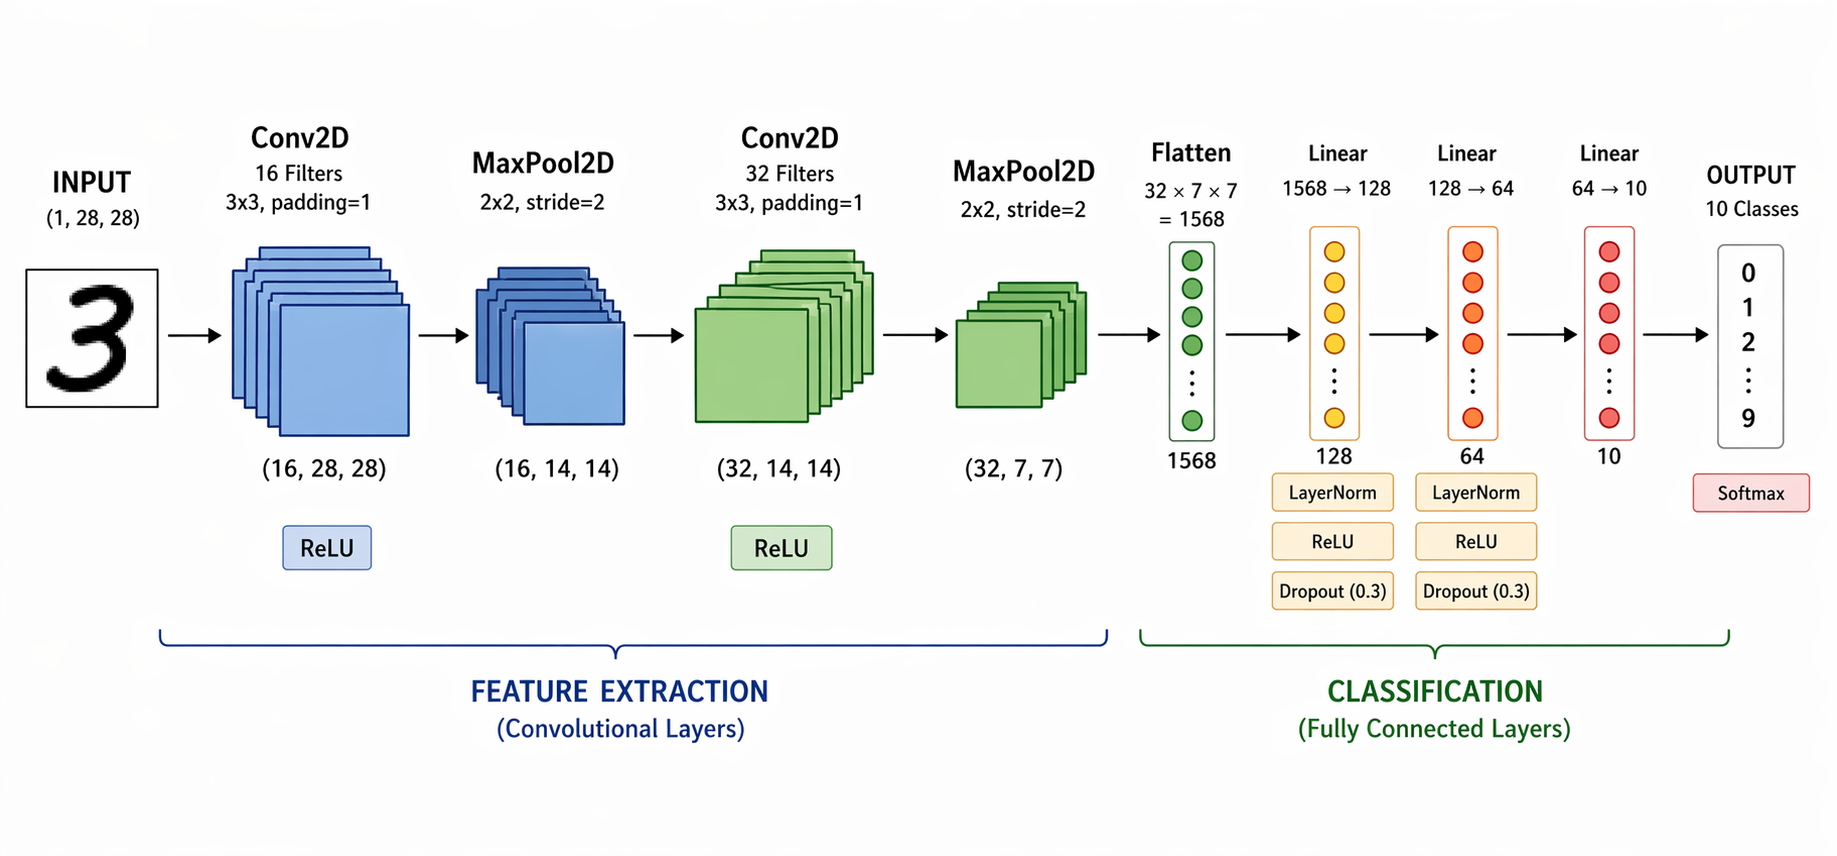

Training step in CNN is no different than the earlier introduced NN one; however, the only difference is the architecture of the layers themselves.

In [16]:
class CNN_Digit_Recognition(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Input: (1, 28, 28)
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # → (16, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # → (16, 14, 14)

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # → (32, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # → (32, 7, 7)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                # → (32*7*7 = 1568)
            nn.Linear(1568, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 10)
        )

        self.loss_fn = nn.CrossEntropyLoss()
        self.apply(self._init_weights_)   
         
    def _init_weights_(self, module):
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def training_step(self, train_dataloader, val_dataloader, epochs, lr=0.01):
        optimizer = optim.SGD(self.parameters(), lr=lr)

        history = {"train_loss": [], "val_loss": [],
                   "train_acc": [], "val_acc": []}

        for epoch in range(epochs):

            # Training
            self.train()
            running_loss, correct, total = 0.0, 0, 0

            for images, labels in train_dataloader:
                optimizer.zero_grad()

                outputs = self(images)   # (batch, 1, 28, 28)
                loss = self.loss_fn(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * labels.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            train_loss = running_loss / total
            train_acc = correct / total

            # Validation
            self.eval()
            val_loss_sum, val_correct, val_total = 0.0, 0, 0

            with torch.no_grad():
                for images, labels in val_dataloader:
                    outputs = self(images)
                    loss = self.loss_fn(outputs, labels)

                    val_loss_sum += loss.item() * labels.size(0)
                    preds = outputs.argmax(dim=1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            val_loss = val_loss_sum / val_total
            val_acc = val_correct / val_total

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        return history

Epoch 1/20 | Train Loss: 0.9464 Acc: 0.7089 | Val Loss: 0.2898 Acc: 0.9207
Epoch 2/20 | Train Loss: 0.4122 Acc: 0.8866 | Val Loss: 0.1746 Acc: 0.9475
Epoch 3/20 | Train Loss: 0.2931 Acc: 0.9225 | Val Loss: 0.1470 Acc: 0.9578
Epoch 4/20 | Train Loss: 0.2365 Acc: 0.9376 | Val Loss: 0.1143 Acc: 0.9657
Epoch 5/20 | Train Loss: 0.1963 Acc: 0.9480 | Val Loss: 0.1019 Acc: 0.9711
Epoch 6/20 | Train Loss: 0.1693 Acc: 0.9545 | Val Loss: 0.0896 Acc: 0.9731
Epoch 7/20 | Train Loss: 0.1541 Acc: 0.9577 | Val Loss: 0.0820 Acc: 0.9762
Epoch 8/20 | Train Loss: 0.1379 Acc: 0.9628 | Val Loss: 0.0776 Acc: 0.9772
Epoch 9/20 | Train Loss: 0.1271 Acc: 0.9663 | Val Loss: 0.0748 Acc: 0.9782
Epoch 10/20 | Train Loss: 0.1188 Acc: 0.9670 | Val Loss: 0.0708 Acc: 0.9791
Epoch 11/20 | Train Loss: 0.1099 Acc: 0.9700 | Val Loss: 0.0712 Acc: 0.9791
Epoch 12/20 | Train Loss: 0.0974 Acc: 0.9728 | Val Loss: 0.0657 Acc: 0.9805
Epoch 13/20 | Train Loss: 0.0985 Acc: 0.9732 | Val Loss: 0.0659 Acc: 0.9802
Epoch 14/20 | Train L

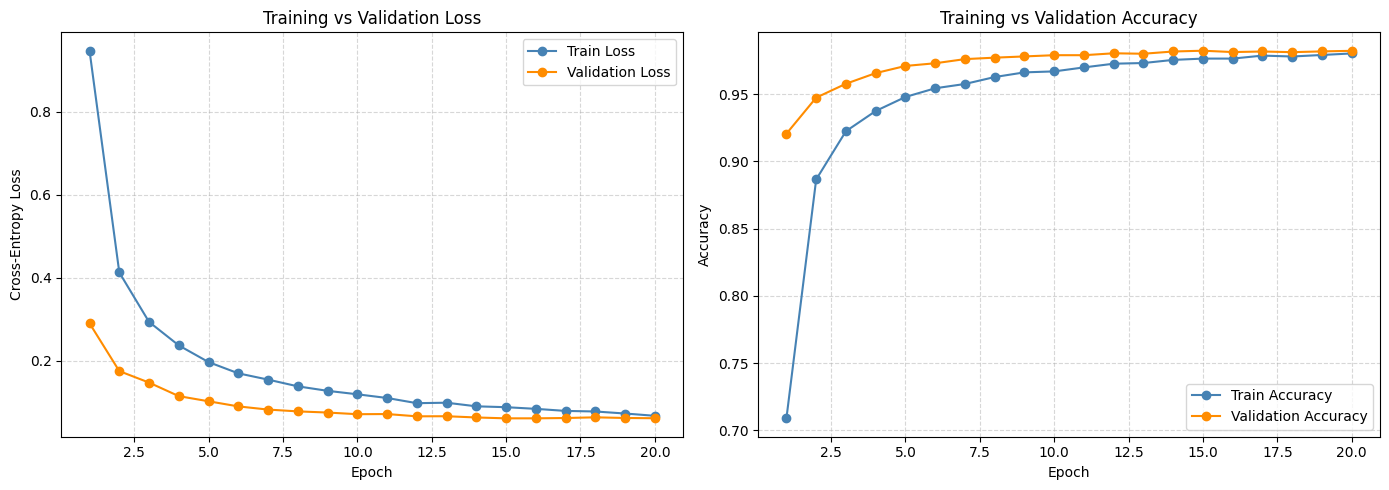

Plot saved → CNN_training_curves.png


In [17]:
def plot_history(history , title_suffix=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    # — Loss plot —
    ax1.plot(epochs, history["train_loss"], label="Train Loss",      color="steelblue",  marker="o")
    ax1.plot(epochs, history["val_loss"],   label="Validation Loss", color="darkorange", marker="o")
    ax1.set_title("Training vs Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)
 
    # — Accuracy plot —
    ax2.plot(epochs, history["train_acc"], label="Train Accuracy",      color="steelblue",  marker="o")
    ax2.plot(epochs, history["val_acc"],   label="Validation Accuracy", color="darkorange", marker="o")
    ax2.set_title("Training vs Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.5)
 
    plt.tight_layout()
    plt.savefig("CNN_training_curves.png", dpi=150)
    plt.show()
    print("Plot saved → CNN_training_curves.png")
 
 
# ─────────────────────────────────────────────
# 6. RUN EVERYTHING
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model   = CNN_Digit_Recognition()
    history = model.training_step( train_loader, val_loader, epochs=20, lr=0.01)
    plot_history(history )

It is noticed that training accuracy improved slightly from 0.9751 in NN to 0.9804 in CNN.

It is noticed that validation accuracy improved slightly from 0.9572 in NN to 0.9823 in CNN.

The following part test accuracy over the test data:

In [18]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 0.98475


It is noticed that accuracy improved slightly from 0.95867 in NN to 0.98475 in CNN.
